### Код для локального сервера

In [ ]:
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import OrdinalEncoder
import torch
from torch import nn
import torch.functional as F
from torch.utils.data import DataLoader, Subset, random_split

from torchvision.transforms import InterpolationMode
from torchvision import models
from torchvision.datasets import VisionDataset
from torchvision.transforms import ToTensor, Resize, Normalize, Compose, RandomResizedCrop, ColorJitter, RandomHorizontalFlip, RandomPerspective, RandomRotation, InterpolationMode, RandomApply, GaussianBlur

import random
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

from PIL import Image

from tqdm import tqdm
import re

import os
import requests

import warnings
warnings.filterwarnings("ignore")

In [ ]:
root_dir = "data"
img_dir = "images"
csv_path = "good_atomic_no_noise_less_noresident.csv"

In [ ]:
def get_idx_row_from_image(img_name, data):
    (id, img_num) = img_name.split(".")[0].split("_")
    id = int(id)
    img_num = int(img_num)
    series = data[(data["ID"] == id) & (data["img_num"] == img_num)]
    idx = series.index[0]
    row = series.iloc[0]

    return (idx, row)

In [ ]:
class Attr(VisionDataset):
    def __init__(self, root_dir, img_dir, csv_path, transform=None):
        self.root_dir = root_dir
        self.img_dir = img_dir
        self.csv_path = csv_path

        super().__init__(self.root_dir, transform=transform)

        self.transform = transform

        self.image_paths = []
        self.labels = []
        self.orig_indices = []

        self._build_dataset()

    def _build_dataset(self):
        data = pd.read_csv(os.path.join(self.root_dir, self.csv_path))
        for img_name in os.listdir(os.path.join(self.root_dir, self.img_dir)):
            #idx = int(img_name.split('.')[0]) // old

            try:
                idx, row = get_idx_row_from_image(img_name, data)
            except:
                continue


            self.labels.append(row.attr_ind)
            self.orig_indices.append(idx)

            img_path = os.path.join(self.root_dir, self.img_dir, img_name)
            self.image_paths.append(img_path)

        print(f"Dataset loaded: {len(self.image_paths)} images")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
default_transform = Compose(
    [Resize((384, 384)), ToTensor(), Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]
)

ds = Attr(transform=default_transform, root_dir=root_dir, img_dir=img_dir, csv_path=csv_path)

Dataset loaded: 13931 images


In [ ]:
train_test_split = 0.9
train_val_split = 1
train_size = int(train_test_split * len(ds))
test_size = len(ds) - train_size
val_size = train_size - int(train_size * train_val_split)
train_size = int(train_size * train_val_split)

generator = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = random_split(ds, [train_size, val_size, test_size], generator=generator)

#### Аугментации

In [ ]:
train_transform = Compose([
    RandomResizedCrop(
        size=(384, 384),
        scale=(0.7, 1.0),
        ratio=(0.9, 1.1)
    ),
    RandomHorizontalFlip(p=0.5),

    ColorJitter(
        brightness=0.2,
        contrast=0.3,
        saturation=0.15,
        hue=0.05
    ),

    RandomApply([
        GaussianBlur(kernel_size=3, sigma=(0.1, 0.7))
    ], p=0.2),

    RandomApply([
        RandomRotation(
            degrees=7,
            interpolation=InterpolationMode.BILINEAR
        )
    ], p=0.3),

    RandomApply([
        RandomPerspective(
            distortion_scale=0.15,
            p=1.0
        )
    ], p=0.2),

    ToTensor(),

    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

default_transform = Compose([
    Resize((384, 384)),
    ToTensor(),
    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

train_ds.transform = train_transform

#### Модельки

In [ ]:
def train_model(model, train_loader, val_loader, epochs, lr, do_val, weights=None):
    criterion = nn.CrossEntropyLoss()
    if weights is not None:
        criterion.weight = weights

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01, betas=(0.9, 0.999))

    history = {"train_loss": []}
    if do_val:
        history["val_acc"] = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        print("Training:")
        for x, y in tqdm(train_loader):
            x = x.to(device)
            y = y.to(device).long()

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_loss = train_loss / len(train_loader)
        history["train_loss"].append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs}:")
        print(f"  Train loss: {avg_loss:.4f}")

        if not do_val:
            continue

        model.eval()
        all_probs = []
        all_preds = []
        all_y = []

        print("Validation:")
        with torch.no_grad():
            for x, y in tqdm(val_loader):
                x = x.to(device)
                y = y.to(device).long()

                out = model(x)
                probs = torch.softmax(out, dim=1)
                preds = torch.argmax(probs, dim=1)

                all_probs.append(probs.cpu())
                all_preds.append(preds.cpu())
                all_y.append(y.cpu())

        all_probs = torch.cat(all_probs).numpy()
        all_preds = torch.cat(all_preds).numpy()
        all_y = torch.cat(all_y).numpy()

        val_acc = accuracy_score(all_y, all_preds)

        print(f"  Val acc: {val_acc:.4f}")

        history["val_acc"].append(val_acc)

    return history

In [ ]:
model = models.efficientnet_v2_s(weights="EfficientNet_V2_S_Weights.DEFAULT")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to C:\Users\User/.cache\torch\hub\checkpoints\efficientnet_v2_s-dd5fe13b.pth


100%|██████████████████████████████████████████████████████████████████████████████| 82.7M/82.7M [01:48<00:00, 801kB/s]


In [ ]:
model = models.efficientnet_v2_s(weights="EfficientNet_V2_S_Weights.DEFAULT")

for p in model.parameters():
    p.requires_grad = False

model.classifier[1] = nn.Linear(model.classifier[1].in_features, 9, bias=True)

#### Треним

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
device

'cuda'

In [ ]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=3, lr=0.001, do_val=True)

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 196/196 [02:54<00:00,  1.12it/s]


Epoch 1/3:
  Train loss: 1.4556
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:18<00:00,  1.19it/s]


  Val acc: 0.5187
  Val micro f1: 0.5187
  Val macro f1: 0.3296
  Val AUC (OvR, macro): 0.8240
Training:


...

  Val acc: 0.5352
  Val micro f1: 0.5352
  Val macro f1: 0.3697
  Val AUC (OvR, macro): 0.8570
Training:


100%|████████████████████████████████████████████████████████████████████████████████| 196/196 [03:01<00:00,  1.08it/s]


Epoch 3/3:
  Train loss: 1.1919
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:19<00:00,  1.12it/s]

  Val acc: 0.5409
  Val micro f1: 0.5409
  Val macro f1: 0.4058
  Val AUC (OvR, macro): 0.8688


In [ ]:
model.modules

<bound method Module.modules of EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=Tr

#### Тюним

батч поменьше

In [ ]:
for p in model.parameters():
    p.requires_grad = True

In [ ]:
k = 0
for p in model.parameters():
    if p.requires_grad:
        k += 1
k

452

In [ ]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

for p in model.features[7].parameters():
    p.requires_grad = True
for p in model.features[6][8:].parameters():
    p.requires_grad = True

hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=1, lr=0.0005, do_val=True)

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 392/392 [03:11<00:00,  2.05it/s]


Epoch 1/1:
  Train loss: 1.0254
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:20<00:00,  1.05it/s]

  Val acc: 0.6521
  Val micro f1: 0.6521
  Val macro f1: 0.6130
  Val AUC (OvR, macro): 0.9307


In [ ]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

for p in model.features[6].parameters():
    p.requires_grad = True
hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=1, lr=0.0001, do_val=True)

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 784/784 [03:05<00:00,  4.23it/s]


Epoch 1/1:
  Train loss: 0.7043
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:19<00:00,  1.15it/s]

  Val acc: 0.6836
  Val micro f1: 0.6836
  Val macro f1: 0.6065
  Val AUC (OvR, macro): 0.9429


In [ ]:
for p in model.features[5].parameters():
    p.requires_grad = True
hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=1, lr=0.00005, do_val=True)

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 784/784 [03:22<00:00,  3.88it/s]


Epoch 1/1:
  Train loss: 0.3697
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:19<00:00,  1.15it/s]

  Val acc: 0.6894
  Val micro f1: 0.6894
  Val macro f1: 0.6448
  Val AUC (OvR, macro): 0.9421


In [ ]:
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)

for p in model.parameters():
    p.requires_grad = True
hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=1, lr=0.00001, do_val=True)

Training:


100%|██████████████████████████████████████████████████████████████████████████████| 1568/1568 [04:26<00:00,  5.88it/s]


Epoch 1/1:
  Train loss: 0.2635
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:19<00:00,  1.11it/s]

  Val acc: 0.6915
  Val micro f1: 0.6915
  Val macro f1: 0.6513
  Val AUC (OvR, macro): 0.9411


#### Тестим

100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:19<00:00,  2.28it/s]

accuracy on class 0: 0.8544
accuracy on class 1: 0.4286
accuracy on class 2: 0.9000
accuracy on class 3: 0.4714
accuracy on class 4: 0.8305
accuracy on class 5: 0.4370
accuracy on class 6: 0.5982
accuracy on class 7: 0.6541
accuracy on class 8: 0.6667

  Test accuracy: 0.6915


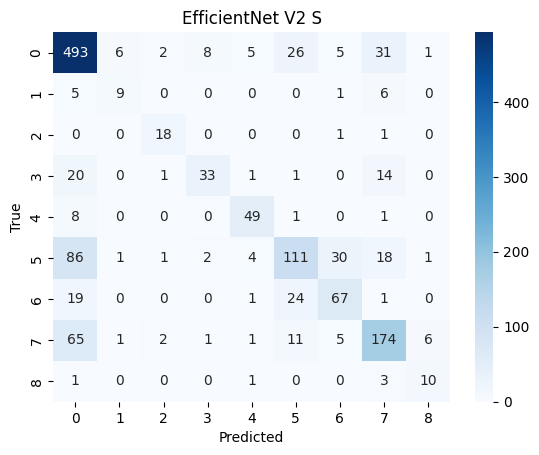

In [ ]:
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

model.eval()
all_preds = []
all_probs = []
all_y = []

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x, y = x.to(device), y.to(device).long()
        out = model(x)

        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_y.append(y.cpu())


all_probs = torch.cat(all_probs).numpy()
all_preds_top3 = np.argsort(all_probs, axis=1)[:,-3:]
all_preds = torch.cat(all_preds).numpy().ravel()
all_y = torch.cat(all_y).numpy().ravel()

test_acc = accuracy_score(all_y, all_preds)
conf_mat = confusion_matrix(all_y, all_preds)

for i in range(9):
    acc = (all_preds[all_y == i] == i).sum() / (all_y == i).sum()
    print(f"accuracy on class {i}: {acc:.4f}")

print()
print(f"  Test accuracy: {test_acc:.4f}")

sns.heatmap(conf_mat, cmap="Blues", annot=True, fmt="d")
plt.title("EfficientNet V2 S")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#### При большой уверенности

In [ ]:
wh = np.where((all_probs > 0.95))
pred = wh[1]
y = all_y[wh[0]]
accuracy_score(y, pred)

0.8552456839309429

In [ ]:
len(y) / len(all_y)

0.5401721664275466

In [ ]:
np.unique(y, return_counts=True)[1] / np.unique(all_y, return_counts=True)[1]

array([0.70190641, 0.42857143, 0.8       , 0.57142857, 0.59322034,
       0.32283465, 0.45535714, 0.56390977, 0.6       ])

In [ ]:
y_prednonzero = y[np.where(pred != 0)]
pred_prednonzero = pred[np.where(pred != 0)]
accuracy_score(y_prednonzero, pred_prednonzero)

0.8227513227513228

In [ ]:
len(y_prednonzero) / len(all_y)

0.27116212338593976

In [ ]:
np.unique(y_prednonzero, return_counts=True)[1] / np.unique(all_y, return_counts=True)[1]

array([0.04679376, 0.33333333, 0.8       , 0.5       , 0.59322034,
       0.27165354, 0.41964286, 0.5037594 , 0.53333333])

#### Всякое

In [ ]:
(conf_mat[0][0] + conf_mat[1:,1:].sum()) / conf_mat.sum().sum()

0.8113342898134863

In [ ]:
conf_mat[:, 1:]

array([[  3,   2,   7,   4,  27,   8,  30,   0],
       [ 11,   0,   1,   0,   0,   0,   4,   0],
       [  0,  17,   0,   0,   2,   0,   0,   0],
       [  0,   1,  30,   0,   0,   0,  15,   0],
       [  0,   0,   0,  46,   2,   2,   3,   0],
       [  0,   1,   2,   4, 114,  44,  23,   0],
       [  0,   2,   0,   1,  23,  65,   2,   0],
       [  1,   3,   4,   1,  13,   1, 181,   1],
       [  0,   1,   0,   1,   0,   0,   2,  11]], dtype=int64)

In [ ]:
conf_mat[:, 0].sum() / conf_mat.sum().sum()

0.48637015781922527

In [ ]:
conf_mat[0, 1:].sum() / conf_mat[:, 1:].sum()

0.11312849162011174

In [ ]:
conf_mat[0, 1:].sum() / conf_mat[:, 1:].sum()

#### За вычетом конфьюжна пересекающихся классов

In [ ]:
k = 0
for pred, true in zip(all_preds, all_y):
    if pred in [5,6] and true in [5,6]:
        k += 1
        continue
    if pred in [5,7] and true in [5,7]:
        k += 1
        continue
    if pred == true:
        k += 1
acc = k / all_y.shape[0]
print(f"light accuracy: {acc:.4f}")

light accuracy: 0.7704


In [ ]:
mat = conf_mat.copy()
wh = np.where(all_probs > 0.999)
preds = wh[1]
y = all_y[wh[0]]
k = 0
for pred, true in zip(preds, y):
    if pred in [5,6] and true in [5,6]:
        k += 1
        continue
    if pred in [5,7] and true in [5,7]:
        k += 1
        continue
    if pred == true:
        k += 1
acc = k / y.shape[0]
acc

0.9523809523809523

In [ ]:
len(y) / len(all_y)

0.23672883787661406

In [ ]:
for i in range(9):
    if conf_mat[i].sum() + conf_mat[:,i].sum() > 1. * (3 * conf_mat[i][i]):
        print(f"{i}: {conf_mat[i].sum() + conf_mat[:,i].sum() - 2 * conf_mat[i][i]} wrong, {conf_mat[i][i]} right")

1: 11 wrong, 6 right
3: 62 wrong, 36 right
6: 100 wrong, 53 right


In [ ]:
np.mean([0.8182, 0.6000, 0.8889, 0.4328, 0.2500, 0.5882, 0.6866, 0.1429, 0.2727, 0.7850,  0.4038,  0.5316,  0.3835,  0.5000])

0.5203000000000001

In [ ]:
probs_argsorted = np.argsort(all_probs, axis=1)
print(f"total objects:  {all_probs.shape[0]}")
for i in range(1, 6):
    k = 0

    mask = ((probs_argsorted[:,-i:]) == all_y[:, None]).any(axis=1)

    for j in probs_argsorted[:,-i:]:
        if 8 in j: k += 1

    print(f"top {i} accuracy:   {np.where(mask)[0].shape[0] / all_probs.shape[0]}")

    print(k)

total objects:  1394
top 1 accuracy:   0.7173601147776184
11
top 2 accuracy:   0.9110473457675753
36
top 3 accuracy:   0.9705882352941176
67
top 4 accuracy:   0.9899569583931134
103
top 5 accuracy:   0.9971305595408895
171


#### Сохранение

In [ ]:
torch.save(model.state_dict(), "models/atomic_classifier/good_classes_efficientnet_v2_s_2.pth")

In [ ]:
model = models.efficientnet_b4()
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 9, bias=True)
model.load_state_dict(torch.load("models/atomic_classifier/good_classes_efficientnet_v2_s.pth", weights_only=True))
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device);